
**Curso: Inteligencia Artificial**

**UNIDAD 2**


---

*   NOMBRE: Jose Enrique Esquivel Torres
*   NO CONTROL: 23110182



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/Analitica_De_Datos/U2/Ejemplos/data.csv"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para preprocesamiento e ing de características
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder,StandardScaler, OrdinalEncoder,FunctionTransformer

# Librerías para la canalización
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline

# Librerías para la regresión
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_squared_error, r2_score, confusion_matrix, precision_score,recall_score,accuracy_score
from sklearn.decomposition import PCA

from sklearn.preprocessing import PolynomialFeatures

---

## **<font color=" #895cf9">Explica brevemente el uso de las librerias del segmento de codigo anterior, haciendo uso de la siguiente tabla</font>**

---

| Library | Explanation  |
|----------|--------------|
|**import pandas as pd**| Se utiliza para manipular y organizar estructuras de datos en tablas. |
|**import numpy as np**| Se utiliza para realizar operaciones matemáticas y cálculos numéricos avanzados. |
|**import matplotlib.pyplot as plt**| Sirve para crear visualizaciones básicas como gráficas estadísticas y diagramas. |
|**import seaborn as sns** | Es una extensión de matplotlib, permite crear visualizaciones bonitas con menos código. |
|**from sklearn.impute import SimpleImputer** | Se utiliza para tratar los datos faltantes o nulos, reemplazándolos por la media, mediana, moda, etc. |
|**from sklearn.preprocessing import MinMaxScaler** | Escala los datos numéricos para que queden dentro de un rango específico, comúnmente entre 0 y 1. |
|**from sklearn.preprocessing import OneHotEncoder** | Convierte variables categóricas de texto a un formato numérico binario de unos y ceros. |
|**from sklearn.preprocessing import StandardScaler** | Estandariza los datos numéricos para que tengan una media de 0 y una desviación estándar de 1. |
|**from sklearn.preprocessing import OrdinalEncoder** | Convierte categorías de texto con un orden específico en valores numéricos ordenados (0, 1, 2, etc.). |
|**from sklearn.preprocessing import FunctionTransformer** | Permite aplicar funciones matemáticas personalizadas o creadas por el usuario a las columnas. |
|**from sklearn.compose import ColumnTransformer** | Permite aplicar diferentes transformaciones a columnas específicas del conjunto de datos. |
|**from sklearn.compose import make_column_selector** | Selecciona automáticamente columnas de un dataset basándose en su tipo de dato (numérico o texto). |
|**from sklearn.pipeline import make_pipeline** | Permite agrupar secuencialmente los pasos de preprocesamiento y el modelo en un solo flujo. |
|**from sklearn.linear_model import LinearRegression**| Modelo de aprendizaje supervisado que se usa para predecir valores numéricos continuos. |
|**from sklearn.linear_model import LogisticRegression** | Modelo matemático que sirve para clasificar y tomar decisiones de 'Sí o No' (binario). |
|**from sklearn.metrics import mean_squared_error**| Mide el error promedio entre los valores reales y las predicciones del modelo de regresión. |
|**from sklearn.metrics import r2_score**| Indica qué tan bien se ajustan las predicciones del modelo de regresión a los datos reales (0 a 1). |
|**from sklearn.metrics import confusion_matrix**| Muestra el resumen de aciertos y errores detallados de un modelo de clasificación. |
|**from sklearn.metrics import precision_score**| Mide el porcentaje de aciertos positivos dentro de todo lo que el modelo predijo como positivo. |
|**from sklearn.metrics import recall_score**| Mide la proporción de casos positivos reales que el modelo fue capaz de identificar correctamente. |
|**from sklearn.metrics import accuracy_score**| Calcula el porcentaje general de predicciones correctas hechas por el modelo de clasificación. |
|**from sklearn.decomposition import PCA**| Reduce el número de variables reduciendo la dimensionalidad del dataset sin perder la información más importante. |
|**from sklearn.preprocessing import PolynomialFeatures**| Genera nuevas características mediante combinaciones polinómicas para modelar relaciones no lineales. |







---

In [ ]:
#lectura del .csv con pandas
data_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Analitica_De_Datos/U2/Ejemplos/data.csv")
data_df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


# **Parte 1**. EDA

Haz que el `id` sea el índice del dataframe y efectúa una exploración inicial de los datos a través de:

In [ ]:
#utilice funcion .set_index()
#Guarde los cambios con inplace=True

#-----------------------------------------------------
#Escriba su codigo
#-----------------------------------------------------
data_df.set_index('id', inplace=True)
data_df
#-----------------------------------------------------


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820


En esta parte se manda como indice a `id` para que el data frame no genere la columna separada que hace siempre que se crear el data frame

In [ ]:
#Desgloce de todas las columnas del data frame
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                 

Desglosamos todas las columnas con `.info()` para saber su tipo de dato, como se ve en su mayoria son de tipo `float64` y solo una de tipo `object` que es la de **"diagnosis"**

In [ ]:
#Determinar la cantidad de valores unicos por columna
data_df.nunique()

,0
diagnosis,2
radius_mean,456
texture_mean,479
perimeter_mean,522
area_mean,539
smoothness_mean,474
compactness_mean,537
concavity_mean,537
concave points_mean,542
symmetry_mean,432


Listamos los valores unicos por cada una de las columnas con `.nunique()`

In [ ]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


Se describen cada una de las columnas con `.describe()` y utilizamos `.T` para trasponer osea cambiamos columnas por filas y viceversa



1a) Estadísticas descriptivas para todas las variables del dataframe.

In [ ]:
#.describe para variables Numericas
#-----------------------------------------------------
data_df.describe(include='number').T
#-----------------------------------------------------

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


Aplicamos lo de antes pero ahora solo para las variables numericas con `include=number` dentro de `.describe()`

In [ ]:
#.describe() para variable categoricas
#-----------------------------------------------------
data_df.describe(include=['object','bool', 'category']).T
#-----------------------------------------------------

,count,unique,top,freq
diagnosis,569,2,B,357


Se hace lo mismo que antes pero con la diferencia de un arreglo dentro de `include` que busca variables categoricas de tipo `object, bool, category`

1b) Valores únicos por variable para identificar posibles variables categóricas.

In [ ]:
# Se hace una lista de variables numéricas y otra de categóricas.
#-----------------------------------------------------
num_cols = data_df.select_dtypes(include=np.number).columns.tolist() #para variables numericas
cat_cols = data_df.select_dtypes(exclude=np.number).columns.tolist() #para variables Categoricas
#-----------------------------------------------------

In [ ]:
# Recuento de cada categoría única en las variables categóricas
for column in cat_cols:
    print(column)
    print(data_df[column].value_counts())
    print('-' * 50)

#Forma numero 2, en este caso como solo es una se puede hacer asi tambien
print("Forma #2")
print("Recuento de cada categoria unica de las variables categoricas")
data_df['diagnosis'].value_counts()

diagnosis
diagnosis
B    357
M    212
Name: count, dtype: int64
--------------------------------------------------
Forma #2
Recuento de cada categoria unica de las variables categoricas


,count
diagnosis,
B,357
M,212


Utilizamos la primera forma con la cual utilizando la variable `cat_cols` que es para la lista de las variables categoricas, dentro de un ciclo `for` el cual itera sobre cada columan de las variables categoricas, y cuenta cada uno de los valores que este tiene, en este caso solo son dos **B** y **M**. Hay una segunda forma para este caso la cual es solo con `data_df['diagnosis'].value_counts()` esta se puede realizar gracias a que solo es una variable categorica entre todas las del data frame.

1c) Búsqueda de valores faltantes.

In [ ]:
#Explica cada linea de codigo
print('Número valores faltantes: ') #imprime en pantalla un mensaje
for col in data_df.columns: #iteracion for entre cada columna del data frame
  valor=sum(data_df[col].isna()) #suma cuantos valores faltan dentro de cada columna
  porcentaje=data_df[col].isna().mean()*100 #calcula el porcentaje total de valores faltantes por cada columna
  print('{}:{}: porcentaje :{}'.format(col,valor,porcentaje)) #arroja el resultado completo de valores y porcentajes faltantes por cada una de las columnas

Número valores faltantes: 
diagnosis:0: porcentaje :0.0
radius_mean:0: porcentaje :0.0
texture_mean:0: porcentaje :0.0
perimeter_mean:0: porcentaje :0.0
area_mean:0: porcentaje :0.0
smoothness_mean:0: porcentaje :0.0
compactness_mean:0: porcentaje :0.0
concavity_mean:0: porcentaje :0.0
concave points_mean:0: porcentaje :0.0
symmetry_mean:0: porcentaje :0.0
fractal_dimension_mean:0: porcentaje :0.0
radius_se:0: porcentaje :0.0
texture_se:0: porcentaje :0.0
perimeter_se:0: porcentaje :0.0
area_se:0: porcentaje :0.0
smoothness_se:0: porcentaje :0.0
compactness_se:0: porcentaje :0.0
concavity_se:0: porcentaje :0.0
concave points_se:0: porcentaje :0.0
symmetry_se:0: porcentaje :0.0
fractal_dimension_se:0: porcentaje :0.0
radius_worst:0: porcentaje :0.0
texture_worst:0: porcentaje :0.0
perimeter_worst:0: porcentaje :0.0
area_worst:0: porcentaje :0.0
smoothness_worst:0: porcentaje :0.0
compactness_worst:0: porcentaje :0.0
concavity_worst:0: porcentaje :0.0
concave points_worst:0: porcentaje :

Con esto podemos ver que las variables numericas estan completas no tienen ningun valor faltante y su porcentaje de igual forma es `0.0`, por lo tanto los datos estan completos y no hace falta usar nada para complementarlos.

1d) Diagrama de barras para determinar la frecuencia de los diagnósticos (cantidad de observaciones con resultado benigno y maligno)

/tmp/ipykernel_4421/3326737552.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_df, x='diagnosis', palette=['green', 'red'], order=['B', 'M'])


Text(0, 0.5, 'Cantidad de Observaciones')

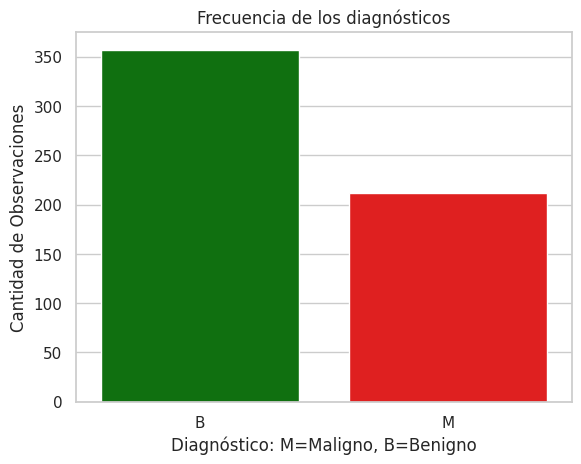

In [ ]:
#utilice sns.countplot()
#-----------------------------------------------------
sns.set_theme(style="whitegrid")
sns.countplot(data=data_df, x='diagnosis', palette=['green', 'red'], order=['B', 'M'])
plt.title('Frecuencia de los diagnósticos')
plt.xlabel('Diagnóstico: M=Maligno, B=Benigno')
plt.ylabel('Cantidad de Observaciones')
#-----------------------------------------------------

La variable `diagnosis` que seria el **diagnostico** tiene dos casos los cuales son Malignos: M, y Beningnos: B.

Mediante la realizacion de la grafica podemos contemplar si los dos casos son iguales o diferentes, pero como se muestra que las el recuento de `Beningno: "B"`, es mucho mayor a los `Malignos: "M"` en este caso.

2. Como hay tres valores relacionados con la misma característica (`mean`, `se` y `worst`) es muy probable que exista multicolinealidad en el conjunto.

La multicolinealidad en regresión es una condición que ocurre cuando algunas variables predictoras están fuertemente correlacionadas entre sí, de tal manera que si se incluyen simultáneamente en un modelo, impiden explicar de manera correcta el efecto que cada una tiene sobre la variable respuesta. Existen muchas formas de analizar si hay colinealidad en los modelos, una de ellas es el alto coeficiente de correlación entre variables.

Para observar este efecto, elabora un mapa de calor que cuantifique la correlación de las variables numéricas en el dataframe.

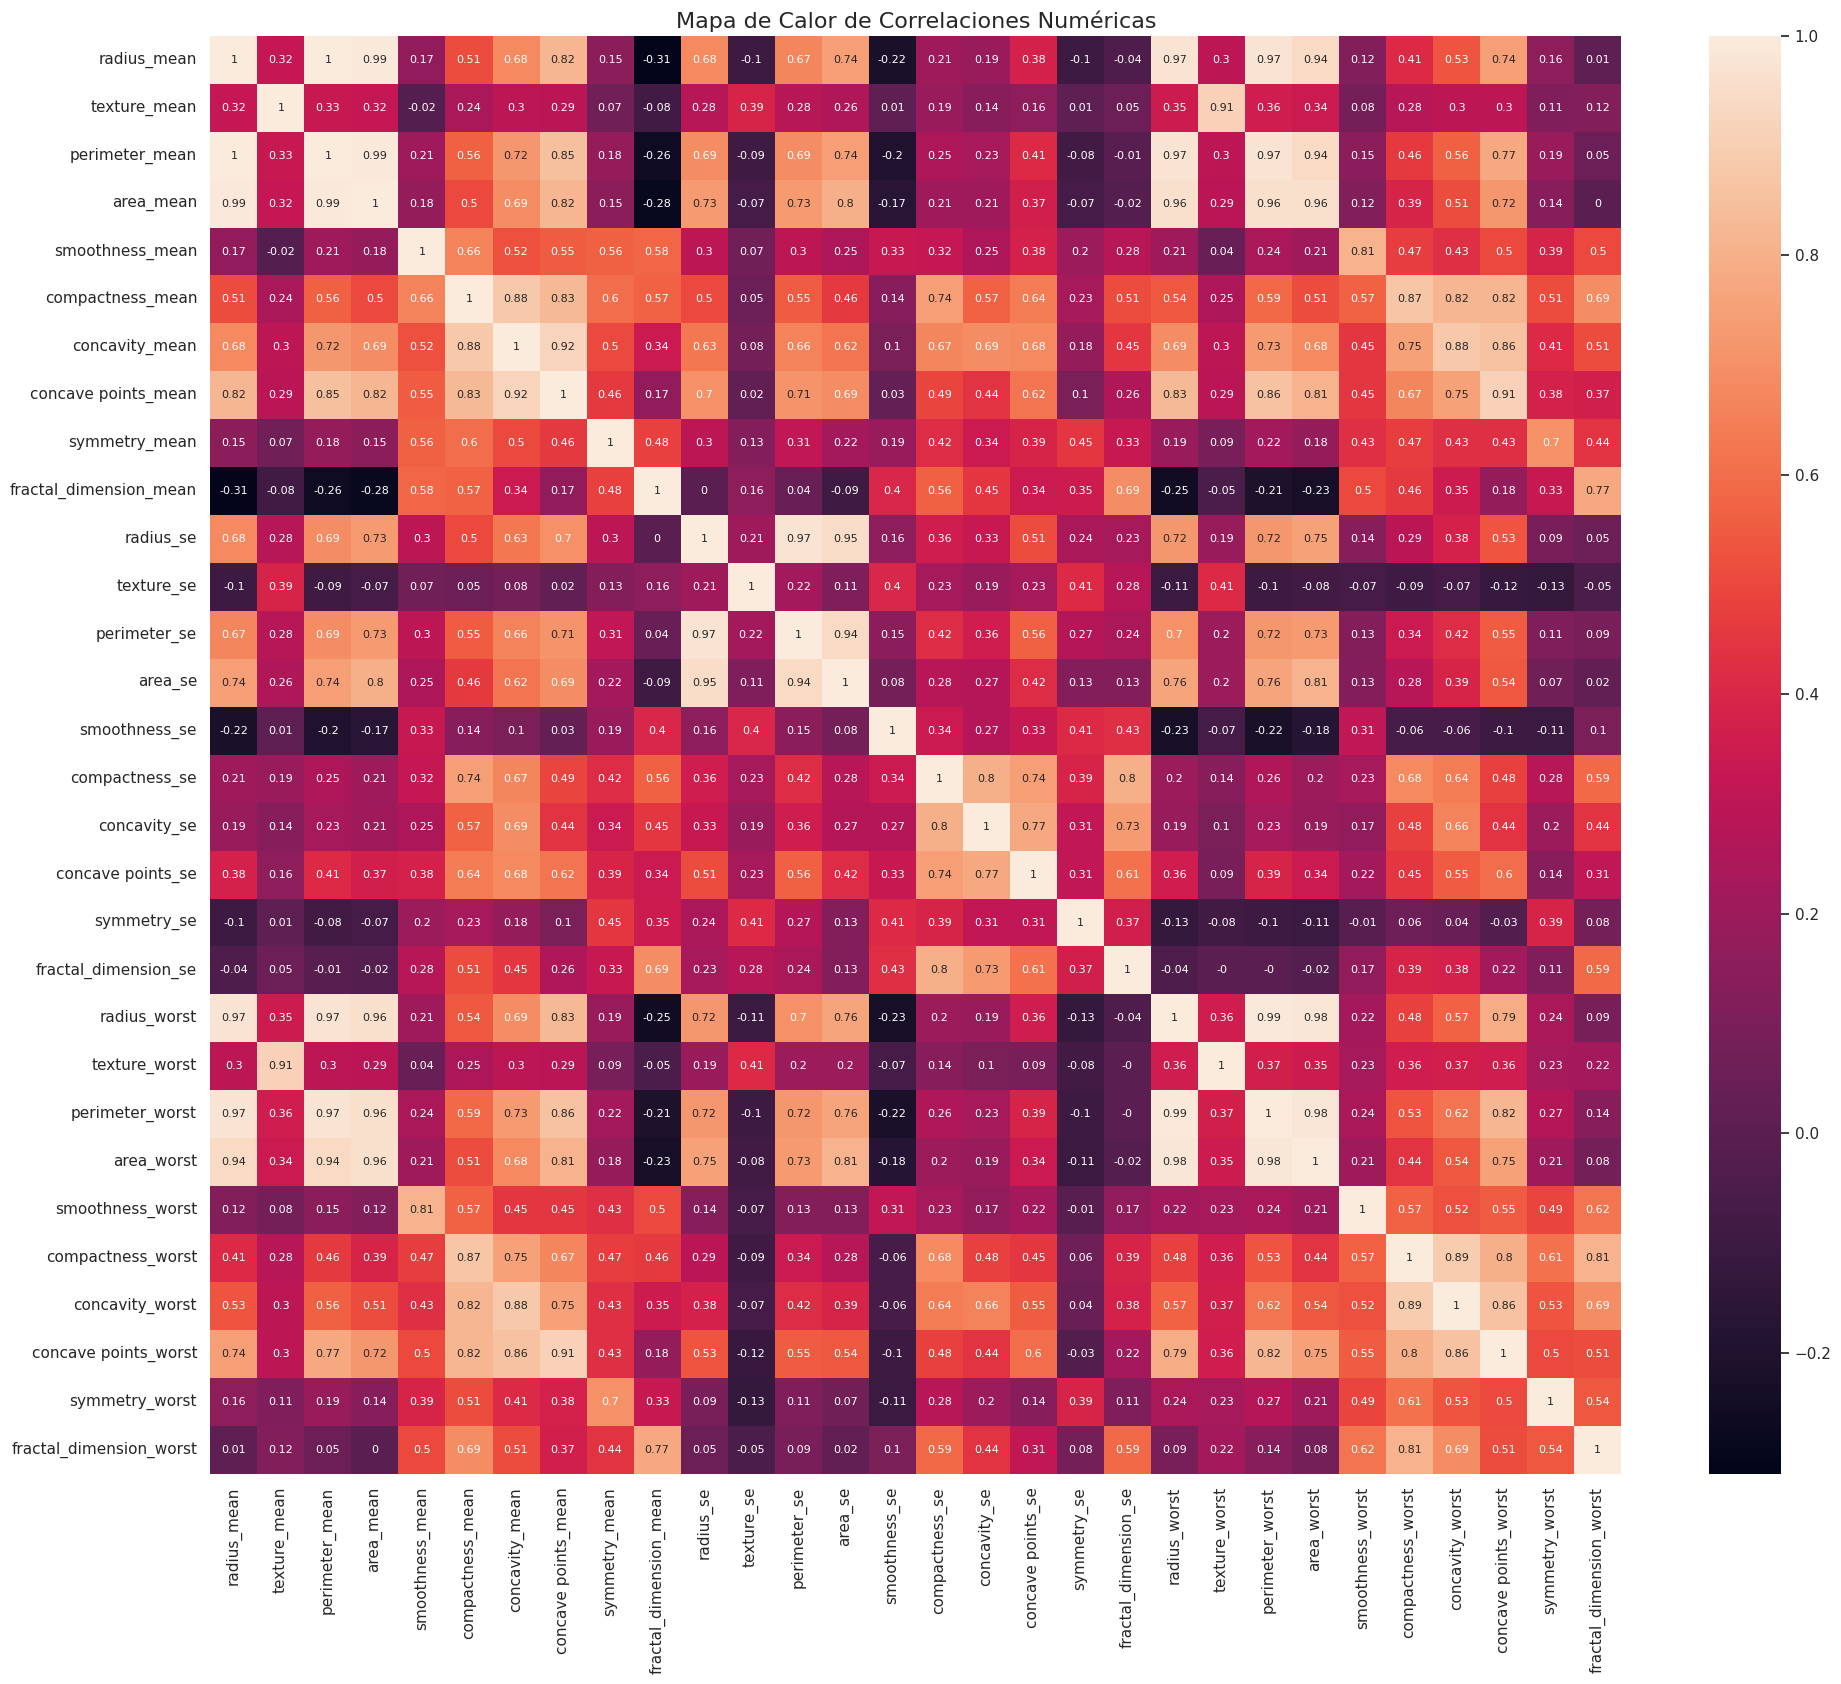

In [ ]:
# esta variable es para seleccionar solos los datos de tipo float e int del data frame
numeric_df = data_df.select_dtypes(include=[float, int])

#-----------------------------------------------------
plt.figure(figsize=(20, 17)) #COnfiguramos una medida mayor para que el diagrma salga bien
sns.heatmap(round(numeric_df.corr(numeric_only=True), 2), annot=True, cmap='rocket', annot_kws={'size': 8}) # aqui desplegamos el diagrama con solo las variables numericas del data frame
plt.title('Mapa de Calor de Correlaciones Numéricas', fontsize=16) #titulo del diagrama
plt.tight_layout()
#-----------------------------------------------------

Se puede observar por el diagrama que hay distintas variables las cuales tienen una relacion muy fuerte, fuera del centro que es 1, hay variables dispersas con relacion fuerte y ademas de eso una segunda columna la cual esta muy relacionada em forma diagonal, de `radus_worst` hasta `fractal_dimension_mean` que va de entre `0.70 - 0.97`.

Si te fijas en los valores de correlación entre las variables `_mean` y `_worst` es evidente la multicolinearidad.

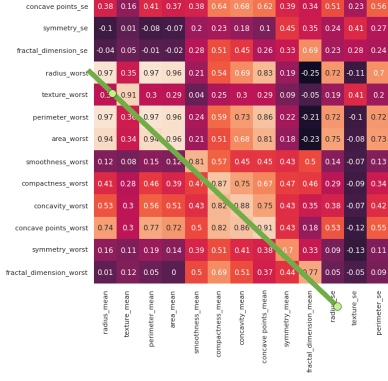

Por ejemplo, la columna `radius_mean` tiene una correlación de 0.97 con la columna `radius_worst`. Esto es algo inevitable, porque las columnas "peores" son esencialmente solo un subconjunto de las columnas "medias".

Para solucionar el problema numérico de la multicolinealidad, tradicionalmente se recurre a eliminar variables o efectuar análisis de componentes principales (PCA) con las `X`’s y usar los componentes como variables independientes en un modelo final.

Conduciremos esta actividad en esos dos sentidos.


# **Parte 2**. Modelo con eliminación de variables altamente correlacionadas  

Elimina las variables altamente correlacionadas:

3a) Ahora que sabes que las variables `_mean` y `_worst` tienen correlación alta, hay que quitar del dataframe un conjunto. Borra las columnas `_worst`.

In [ ]:
#-----------------------------------------------------
#Elimine TODAS las columnas _worst

#-----------------------------------------------------

#para borrar las columnas _worst
for col in data_df.columns:
  if '_worst' in col:
    data_df.drop(col, axis=1, inplace=True)

#-----------------------------------------------------
#Convierte new_data_df en Dataframe usando .DataFrame() de la libreria de pandas

new_data_df=pd.DataFrame(data_df)
new_data_df

#-----------------------------------------------------

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892


En las graficas de dispersion, los patrones lineales en los diagramas de dispersion se refieren a la relacion entre dos variables que sigue una tendencia aproximadamente en linea recta, ya sea en direccion ascendente o descentende

* **Patron lineal positivo**: Si la linea se inclina hacia arriba (de izquierda a derecha), indica que hay una relacion directa entre las variables: cuando la variable aumenta, la otra tambien lo hace, es decir, CORRELACION POSITIVA

* **Patron lineal negativo**: si la linea se incluna hacia abajo (de izquierda a derecha), indica quue cuando una variable aumenta, la otra disminuye, es decir, CORRELACION NEGATIVA

* **Patron lineal perfecto**, si los puntos siguen una linea recta perfecta, la relacion entre las variables es exactamente lineal, sin desviaciones.


3b. Entre las variables `_mean`, identifica patrones lineales con diagramas de dispersión usando:

    sns.pairplot(data=nuevo_df[['radius_mean',
        'texture_mean',
        'perimeter_mean',
        'area_mean',
        'smoothness_mean',
        'compactness_mean',
        'concavity_mean',
        'concave points_mean',
        'symmetry_mean',
        'fractal_dimension_mean']])



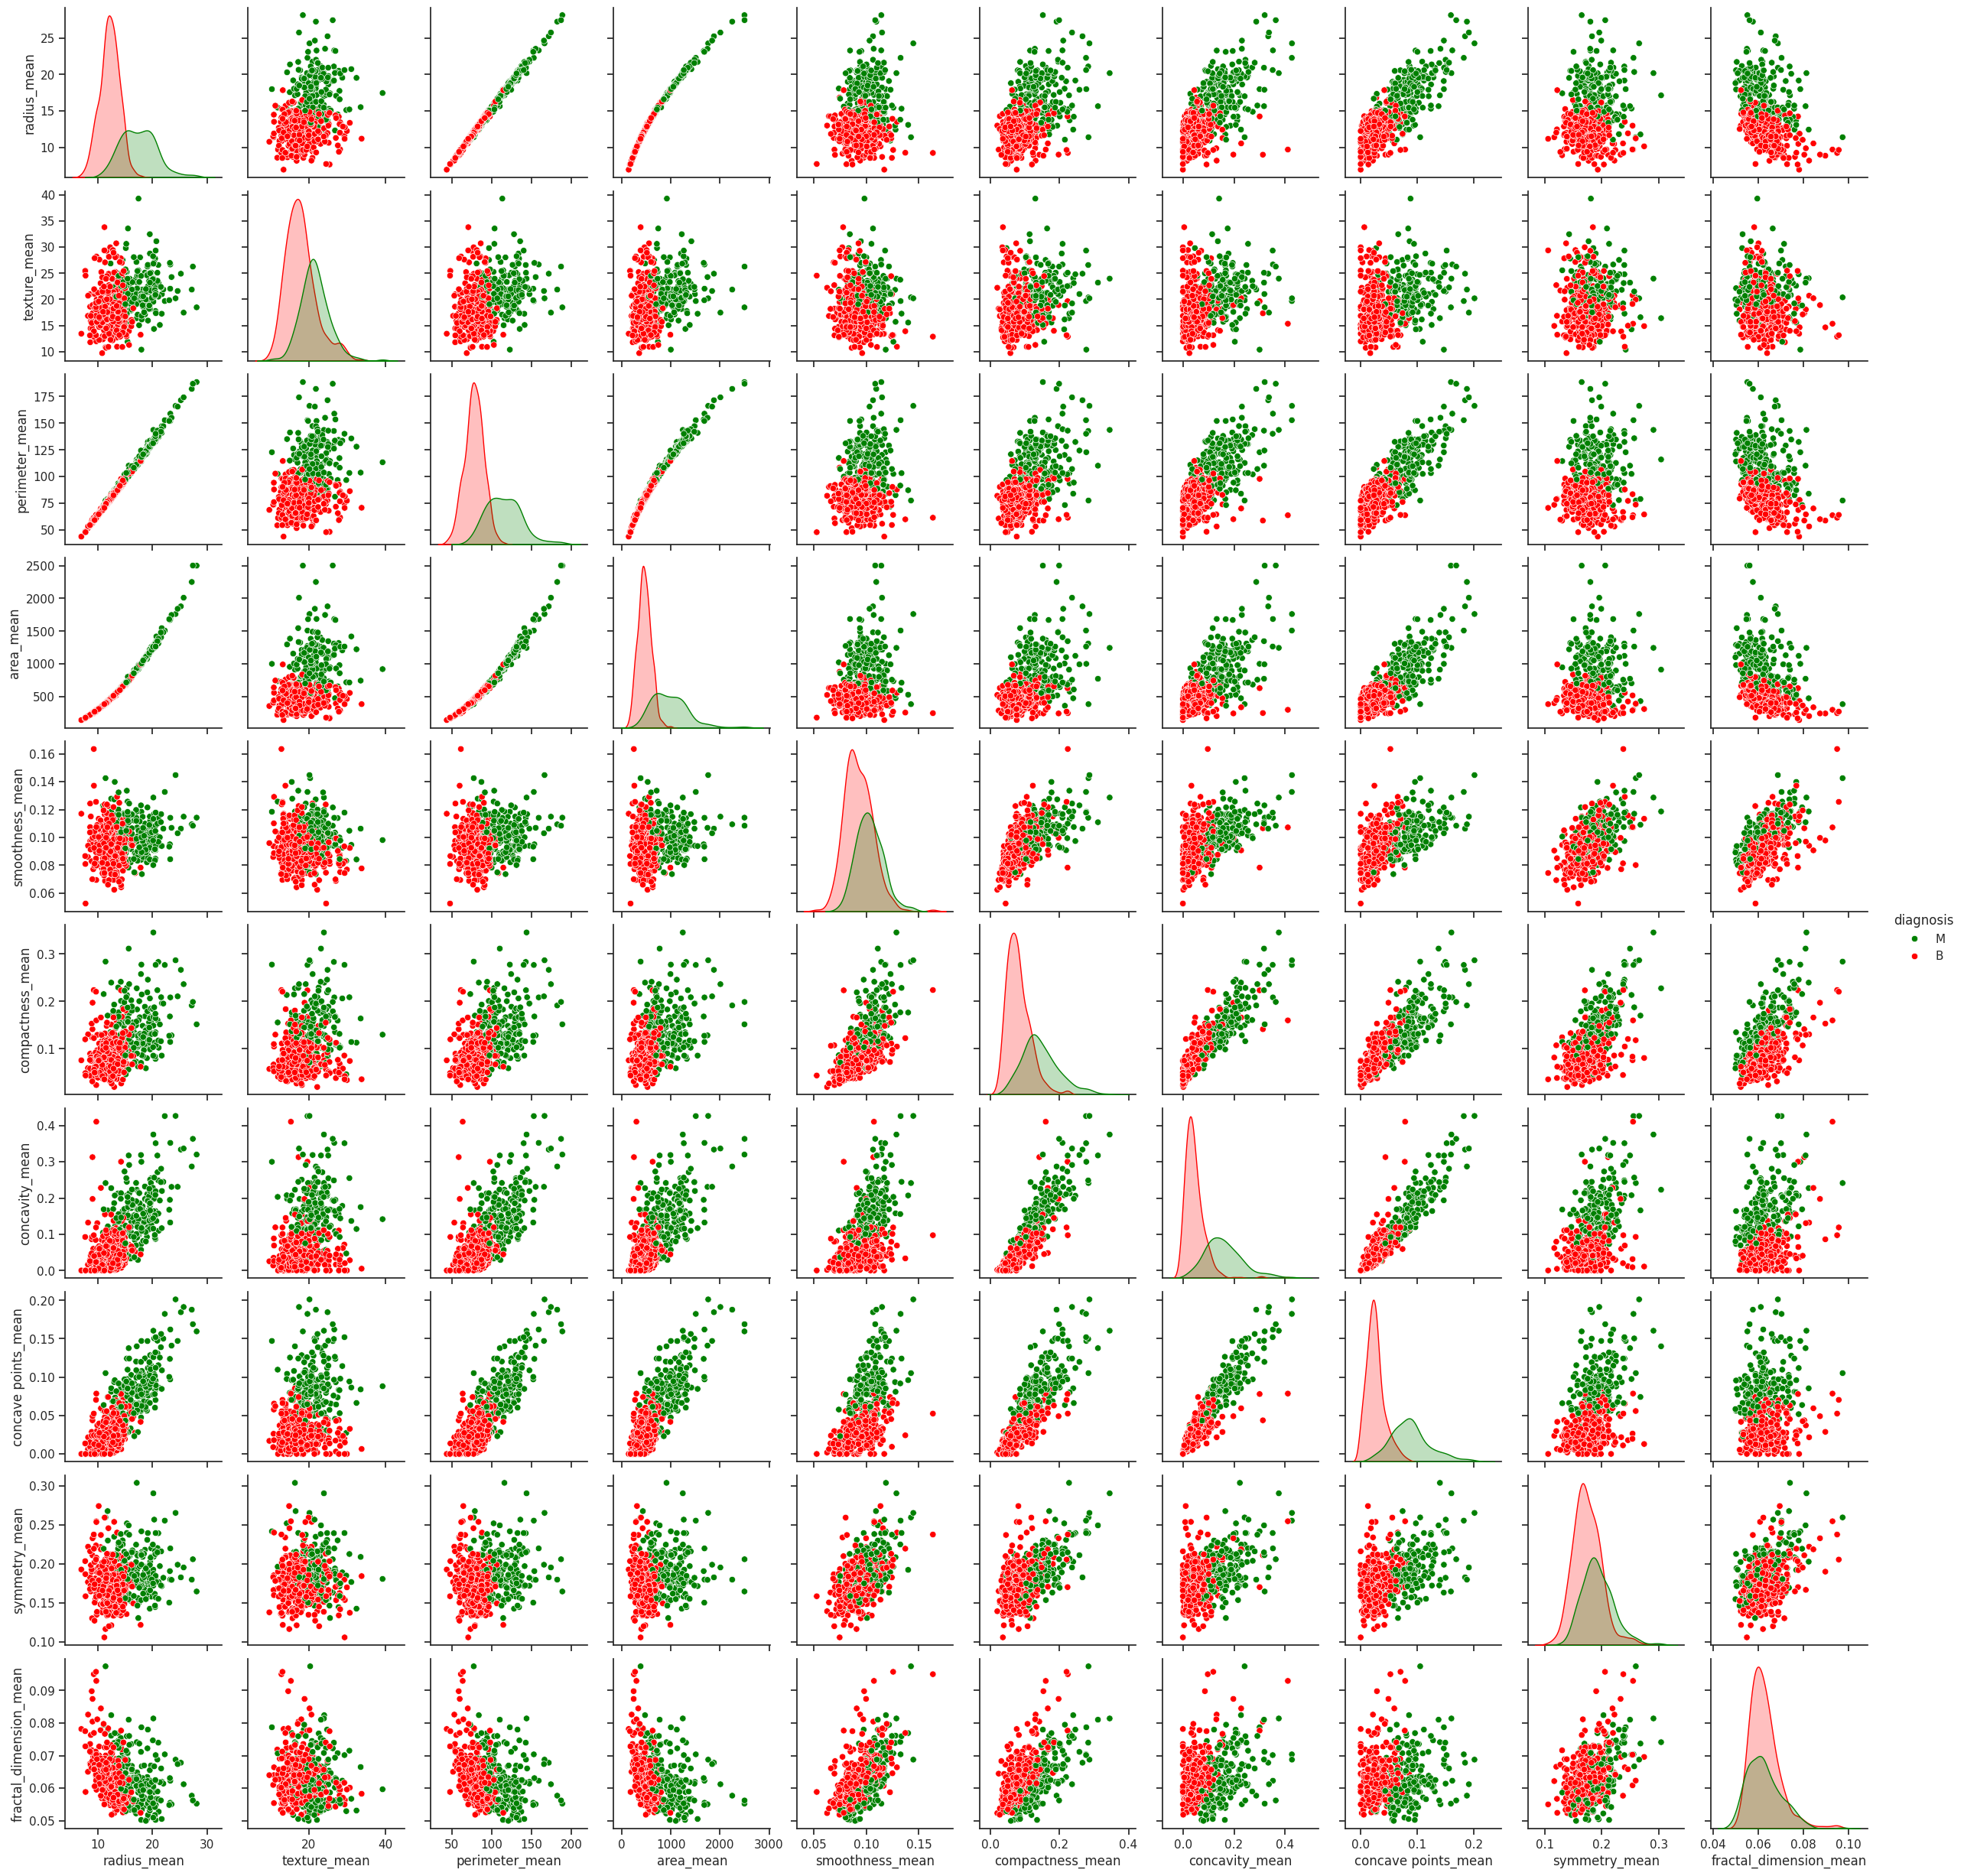

In [ ]:
#-----------------------------------------------------
#Pega aqui el codigo sns.pairplot()
sns.set_theme(style='ticks')
sns.pairplot(
    data_df[['radius_mean',
             'texture_mean',
             'perimeter_mean',
             'area_mean',
             'smoothness_mean',
             'compactness_mean',
             'concavity_mean',
             'concave points_mean',
             'symmetry_mean',
             'fractal_dimension_mean',
             'diagnosis']],
    hue='diagnosis',
    palette=['green', 'red']
)
#-----------------------------------------------------

Se puede observar claramente en las graficas de dispersion que tienen una relacion muy fuerte entre las variables `readius_mean`, `perimeter_mean` y `area_mean`, las cuales forman o se acercan a un patron lineal perfecto en la que las dos variables aumentan de forma constante y en igualdad.

Las otras variables que casi llegan a un patron lineal pero son un patron lineal positivo son `compactness_mean`, `concativy_mean` y `concave points_mean` ya que su dibujo marca una tendencia acendente muy marcada.

De la matriz podrás observar relaciones lineales bastante evidentes entre:


*   `radius_mean`, `perimeter_mean` y `area_mean`
*   `compactness_mean`, `concavity_mean`, `concave_points_mean`

Sabemos que el perímetro y el área de un círculo, se calculan a partir del radio. Entonces, la relación entre las primeras tres variables es muy clara para nosotros.

3c) Elabora otro mapa de calor confirmar con los valores de correlación.


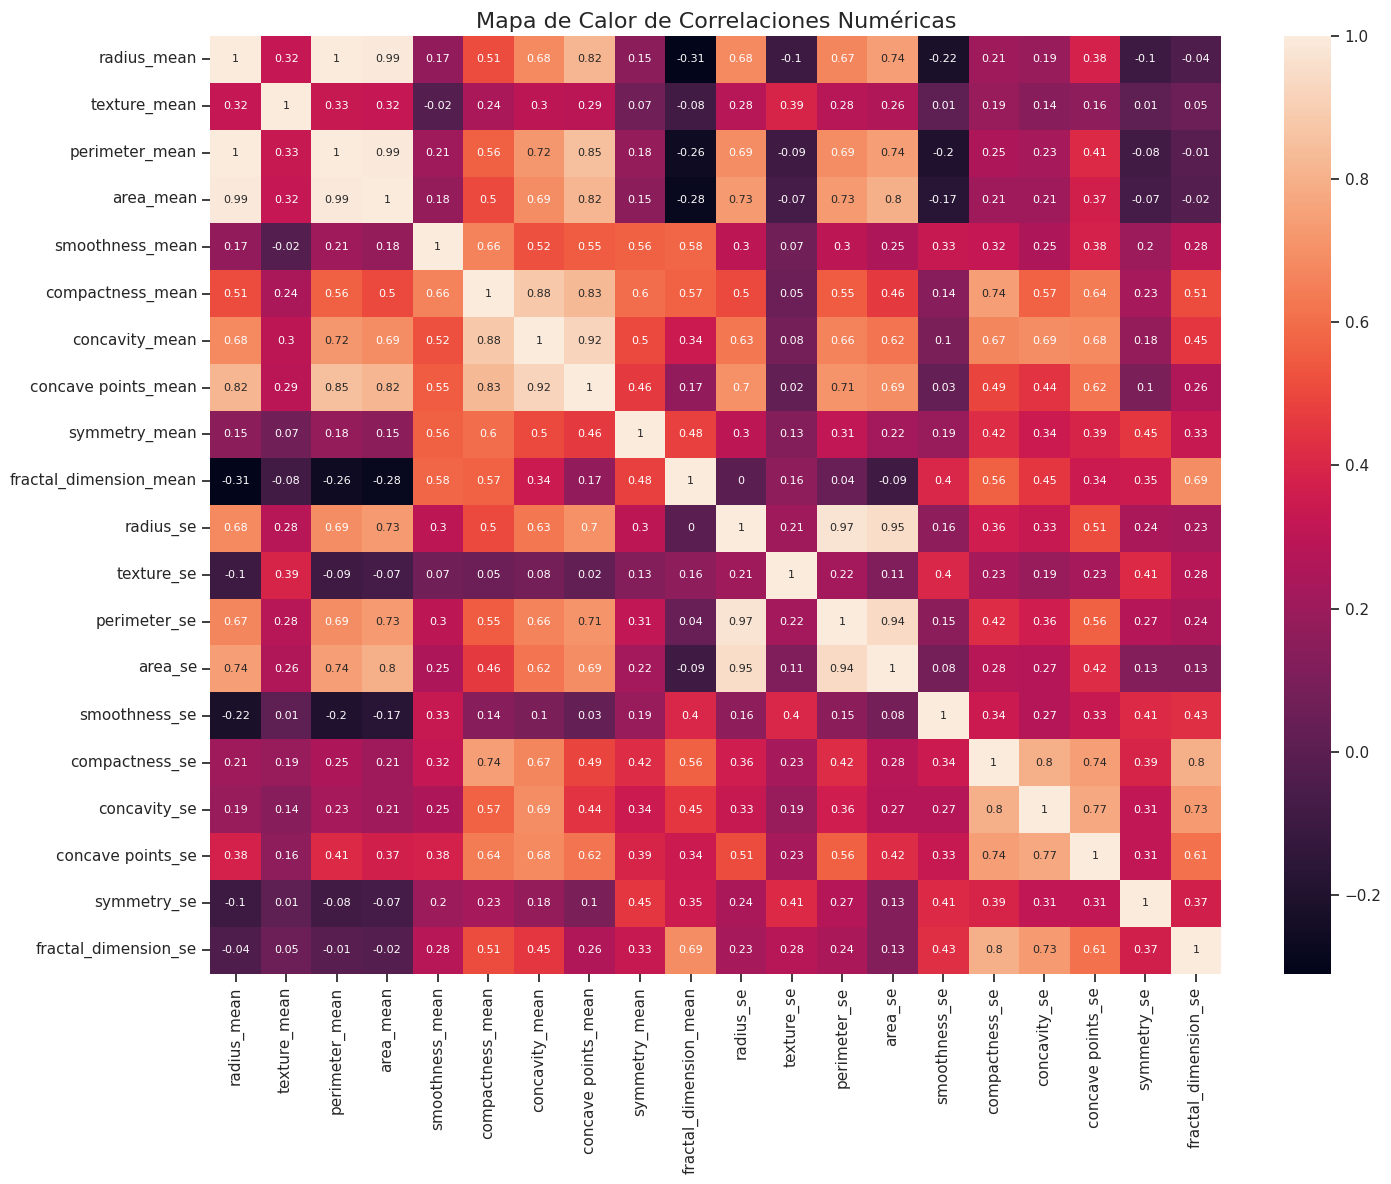

In [ ]:
#-----------------------------------------------------
#Agrega codigo para el mapa de calor
new_numeric_df = new_data_df.select_dtypes(include=[float, int])

#-----------------------------------------------------
plt.figure(figsize=(15, 12))
sns.heatmap(round(new_numeric_df.corr(numeric_only=True), 2), annot=True, cmap='rocket', annot_kws={'size': 8})
plt.title('Mapa de Calor de Correlaciones Numéricas', fontsize=16)
plt.tight_layout()
#-----------------------------------------------------

3d) Después de observar los valores, nos quedaremos con sólo una variable de cada trío: `radius_mean` y `compactness_mean`. Elimina las restantes, no sólo del conjunto `_mean`, sino también de `_se`.

In [ ]:
#-----------------------------------------------------
# escriba TODAS las columnas que seran eliminadas (corregido ortografía)
columnas_a_eliminar = [
  'perimeter_mean',
  'area_mean',
  'concavity_mean',
  'concave points_mean',
  'perimeter_se',
  'area_se',
  'concavity_se',
  'concave points_se'
]
#-----------------------------------------------------

#-----------------------------------------------------
new_data_df_2 = pd.DataFrame(new_data_df.drop(columns=columnas_a_eliminar))
new_data_df_2
#-----------------------------------------------------

,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,symmetry_se,fractal_dimension_se
id,,,,,,,,,,,,,
842302,M,17.99,10.38,0.11840,0.27760,0.2419,0.07871,1.0950,0.9053,0.006399,0.04904,0.03003,0.006193
842517,M,20.57,17.77,0.08474,0.07864,0.1812,0.05667,0.5435,0.7339,0.005225,0.01308,0.01389,0.003532
84300903,M,19.69,21.25,0.10960,0.15990,0.2069,0.05999,0.7456,0.7869,0.006150,0.04006,0.02250,0.004571
84348301,M,11.42,20.38,0.14250,0.28390,0.2597,0.09744,0.4956,1.1560,0.009110,0.07458,0.05963,0.009208
84358402,M,20.29,14.34,0.10030,0.13280,0.1809,0.05883,0.7572,0.7813,0.011490,0.02461,0.01756,0.005115
...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,0.11100,0.11590,0.1726,0.05623,1.1760,1.2560,0.010300,0.02891,0.01114,0.004239
926682,M,20.13,28.25,0.09780,0.10340,0.1752,0.05533,0.7655,2.4630,0.005769,0.02423,0.01898,0.002498
926954,M,16.60,28.08,0.08455,0.10230,0.1590,0.05648,0.4564,1.0750,0.005903,0.03731,0.01318,0.003892


Observa la distribución de las variables resultantes (deben ser 12, sin contar la columna de indice):

4a) Utilizando histogramas. Guarda en una variable (`skew_cols`) las que tengan marcado sesgo positivo. Para dar seguridad a tu selección, elige aquellas cuyo resultado de aplicar la función `skew()` sea mayor a 1.

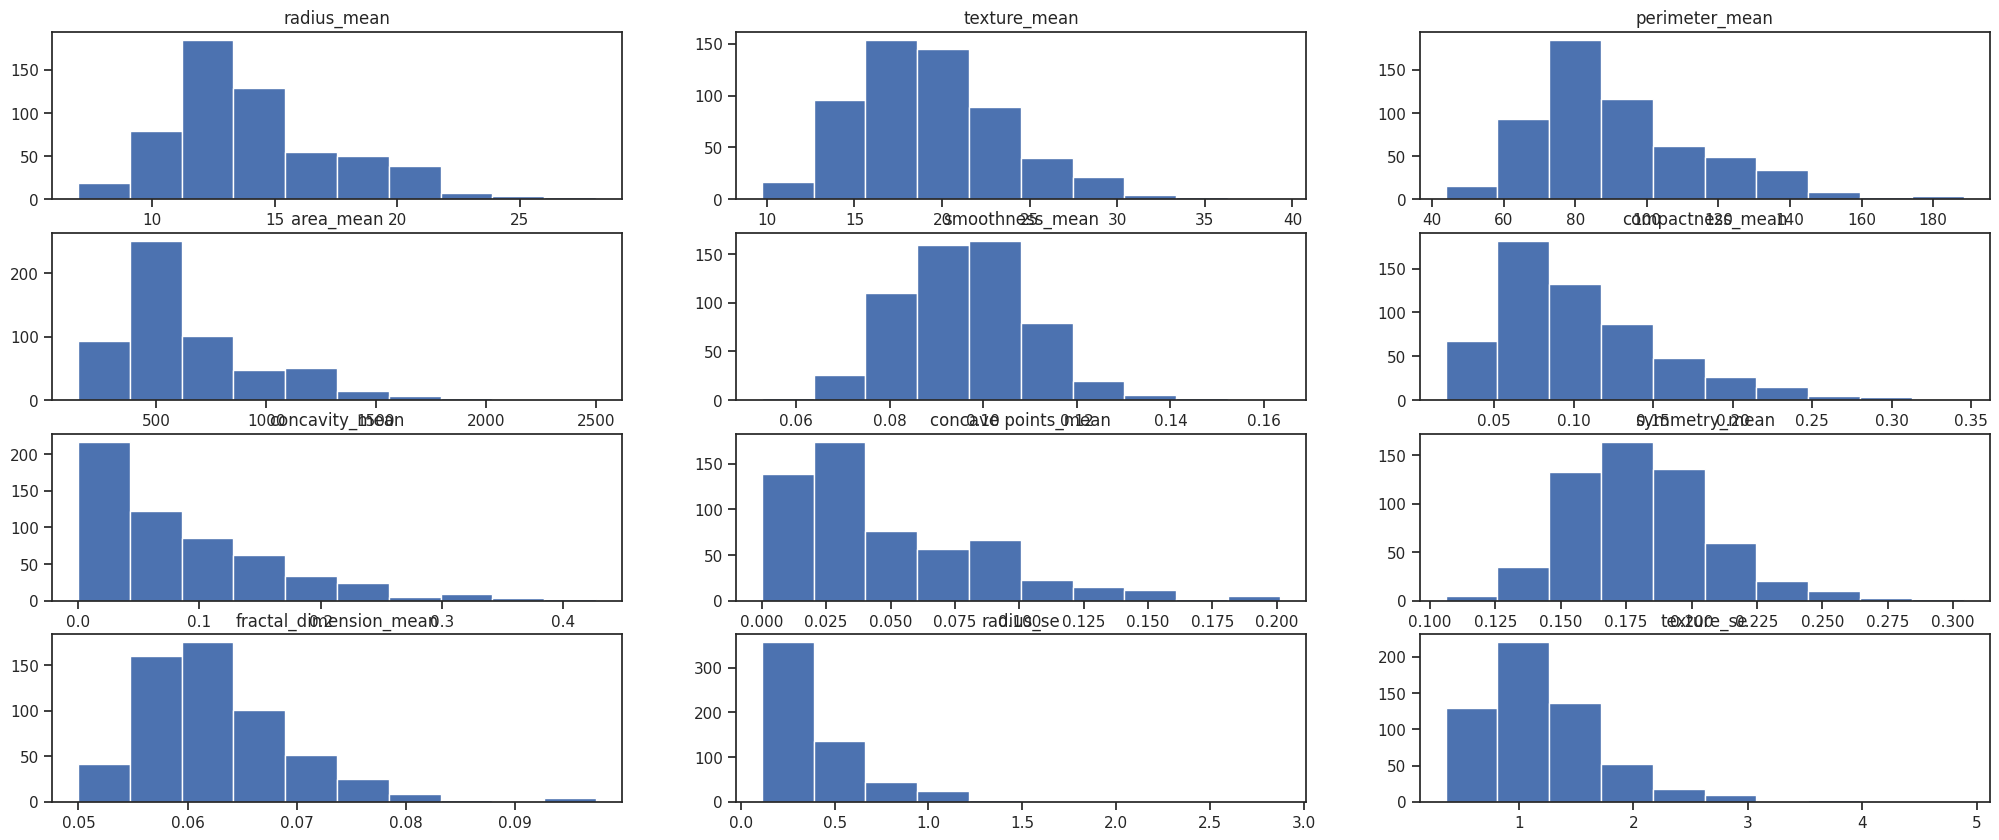

In [ ]:
#EXPLICA CADA LINEA DE CODIGO
skew_cols_df=pd.DataFrame() # crea un data frame vacio
fig, axes =plt.subplots(4,3, figsize=(25,10)) #crea un lienzo para las graficas asi como
# medidas de los histogragamas asi como las columnas y filas en las que aparecera cada uno
axes = axes.ravel() # esto la convierte en un arreglo de 12 elementos gracias a .reveal()
num_cols = new_data_df.select_dtypes(include=np.number).columns.tolist() # con esto solo seleccionamos las columnas que cuentan con variables numericas


for col, ax in zip (num_cols, axes):
  ax.hist(new_data_df[col])
  ax.set(title = f'{col}', xlabel=None)
  if new_data_df[col].skew()>1 : skew_cols_df[col] =new_data_df[col]
# con esto primero iteramos en cada columna asi como espacio del grafico
# luego dibuja un histograma dentro de cada espacio de ax
# anade el titulo dinamicamente a cada uno de los graficos
# evalua la asimetria de los datos de esa columna,  luego si la condicion anterior  cumple copia la columna en el data frame vacio

skew_cols = skew_cols_df.columns.values
# esta parte extre unicamente y guarda en el arreglo los nombres de las columnas con sesgos muy altos


In [ ]:
skew_cols # aqui represnetamos los nombres de las columnas con un sesgo muy alto

array(['area_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'fractal_dimension_mean', 'radius_se',
       'texture_se'], dtype=object)

4b) Dibujando box plots de todas las variables. Guarda en una variable (`scale_cols`) aquellas que no se encuentren en el intervalo [0,1]


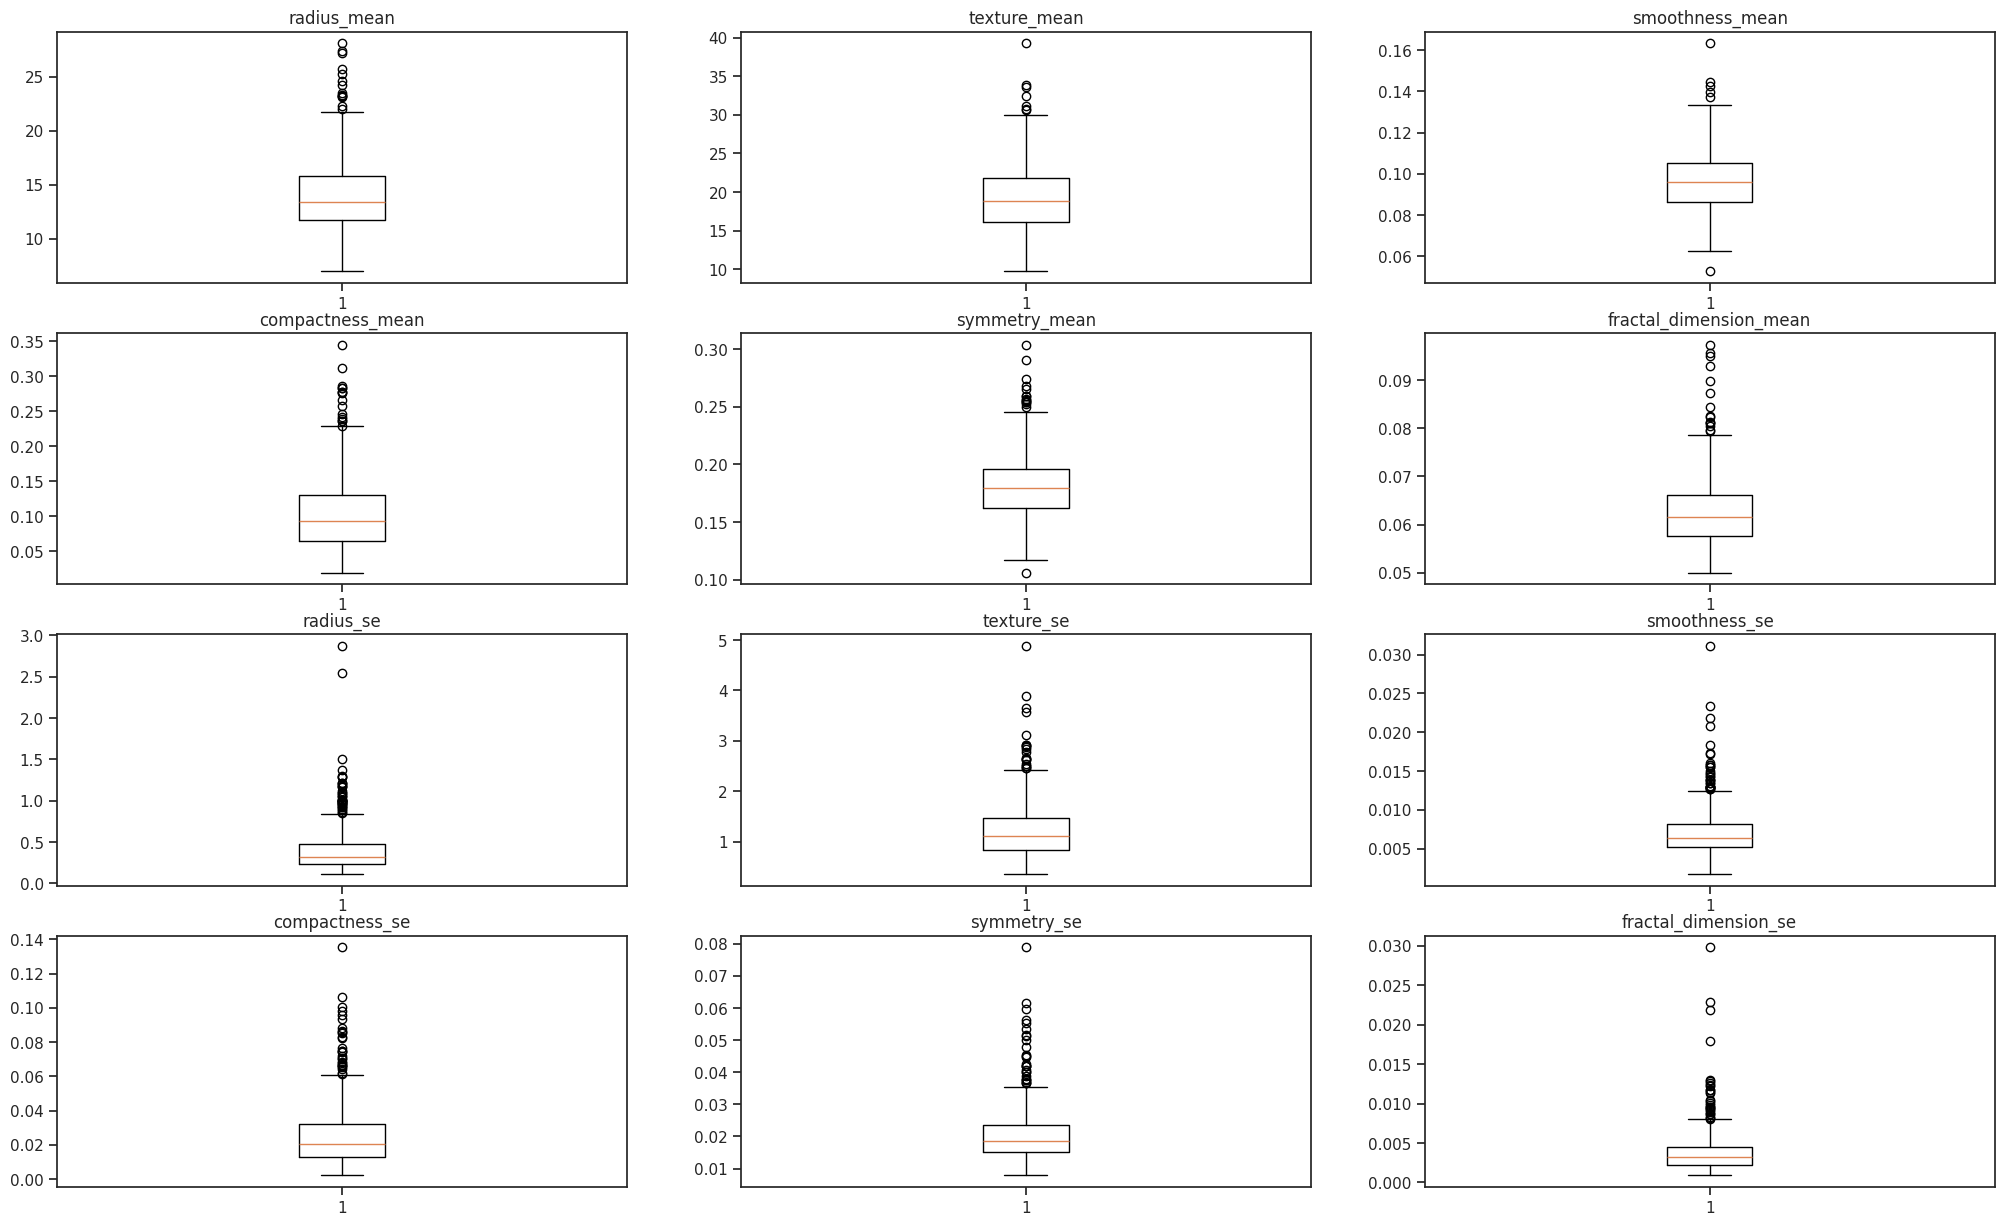

In [ ]:
scale_cols_df = pd.DataFrame()
fig, axes = plt.subplots(4, 3, figsize=(25, 15))
axes = axes.ravel()

# Obtenemos las columnas numéricas de nuestro DataFrame filtrado (new_data_df_2)
num_cols_filtered = new_data_df_2.select_dtypes(include=np.number).columns.tolist()

#-----------------------------------------------------
for col, ax in zip(num_cols_filtered, axes):

  # 1. Dibujamos el boxplot pasando la columna correspondiente de datos
  ax.boxplot(new_data_df_2[col])
  ax.set_title(col)

  # 2. Identificamos variables que NO estén contenidas puramente en el intervalo [0, 1]
  # Es decir, si su máximo es mayor a 1 o su mínimo es menor a 0
  if new_data_df_2[col].max() > 1 or new_data_df_2[col].min() < 0:
    scale_cols_df[col] = new_data_df_2[col]
#-----------------------------------------------------

scale_cols = scale_cols_df.columns.values

In [ ]:
scale_cols

array(['radius_mean', 'texture_mean', 'radius_se', 'texture_se'],
      dtype=object)

Con todo el análisis anterior, estamos listos para generar un modelo *baseline* denominado `logr_model`. Para ello:

5a) Vuelve a leer el contenido del archivo, haz que el `id` sea el índice y separa las variables del dataframe: en `X` coloca los predictores y en `y` la variable de respuesta o salida (`diagnosis`). Divide el conjunto en entrenamiento y prueba (80:20) considerando el parámetro `random_state` con el valor de 1.

In [ ]:
data_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analitica_De_Datos/U2/Ejemplos/data.csv')

#-----------------------------------------------------
#AGREGA LINEA DE CODIGO PARA CONVERTIR COLUMNA "ID" EN INDICE
data_df = data_df.set_index('id')
#-----------------------------------------------------

In [ ]:
X = data_df.copy() #Se crea copia del df


#-----------------------------------------------------
#                                  COMPLETA CODIGO
# se elimina variable Categorica "diagnosis" de (X), debido a se sera utilizada como variable de salida (y)
#-----------------------------------------------------
#Especifique la columna que desea eliminar
#Utilice el parametro axis=1, permitira eliminar la columna
#Guarde los cambios agregando el parametro inplace=True

X.drop('diagnosis', axis=1, inplace=True) #Caracteristica / variable Entrada
#-----------------------------------------------------

#-----------------------------------------------------
y = data_df['diagnosis'] #Objetivo /Variable salida
#-----------------------------------------------------


In [ ]:
# Librería necesaria para realizar la partición del conjunto de datos
from sklearn.model_selection import train_test_split

# Se divide el conjunto en entrenamiento y prueba (80:20), es decir, 80% para Entrenamiento (train) y 20% para Prueba (test)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=1)

5b) Prepara un transformador, denominado `preprocessing`, para borrar las columnas altamente correlacionadas (las 18 variables que se determinaron en los ejercicios previos) Asegúrate de incluir el parámetro `remainder='passthrough'` para mantener el resto de las variables.

In [ ]:
#EXPLIQUE CADA LINEA DE CODIGO
columnas_a_eliminar=['radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst','compactness_worst','concavity_worst','concave points_worst','symmetry_worst','fractal_dimension_worst','perimeter_mean','area_mean','concavity_mean','concave points_mean','perimeter_se','area_se','concavity_se','concave points_se']
#En esta linea anterior se muestra un listado de las columnas que se necesitan eliminar para las columnas que estan alatamente relacionadas

#Este paso esta diseñado exclusivamente para aplicar pasos especificos en las columnas que se seleccionaron
preprocessing = ColumnTransformer([
    ('num', 'drop', columnas_a_eliminar)] #Se indica que aplique drop a las columnas que se decidieron fueran eliminadas
   ,remainder='passthrough') #Esto asegura que las columnas restantes de los datos queden intactas sin ser modificadas o eliminadas


5c) Entrena el modelo `logr_model` con el transformador `preprocessing` y  regresión logística.

Como la salida `y` está en términos de las etiquetas `'B'` y `'M'`, en lugar de 0 y 1, para evaluar el modelo en el conjunto de prueba deberás especificar la clase positiva. En el caso de la matriz de confusión, indica el orden de las etiquetas con `labels=['B','M']`, porque `'B'` es la clase negativa (ésta se especifica primero) y `'M'` la positiva. Para las métricas de *recall* y *precision*, utiliza el parámetro `pos_label='M'`. Como *accuracy* ocupa la suma de ambas clases y el total de las observaciones, no requiere ninguna especificación. Si quisieras omitir estos parámetros, tendrías que sustituir `'B'` por 0 y `'M'` por 1, previo a la construcción del modelo.

In [ ]:
# Creamos la 'tubería' o flujo de trabajo primero aplica nuestro filtro para borrar las columnas repetidas y luego entrenar el modelo
logr_model = make_pipeline(preprocessing, LogisticRegression())

# Entrenamos el modelo usando nuestros datos de práctica de entrada y sus respuestas reales
logr_model.fit(Xtrain, ytrain)

# Le pedimos al modelo que intente adivinar los diagnósticos del conjunto de examen o prueba
predictions = logr_model.predict(Xtest)

# Creamos una matriz de confusiónque compara cuantas veces el modelo acerto y cuantas fallo al predecir
print('matriz de confusion 1:\n', confusion_matrix(ytest, predictions, labels=['B','M']))

#Calculamos el recall de todos los casos que eran realmente
print('recall    :\t', recall_score(ytest, predictions, pos_label='M'))

# Calculamos la presicion de todos los casos que el modelo clasifico
print('precision :\t', precision_score(ytest, predictions, pos_label='M'))

#Calculamos el acurracy el porcentaje general de respuestas correctas
print('accurancy :\t', accuracy_score(ytest, predictions))

matriz de confusion 1:
 [[68  4]
 [10 32]]
recall    :	 0.7619047619047619
precision :	 0.8888888888888888
accurancy :	 0.8771929824561403


### **Análisis del Modelo 1 (Baseline)**

* **Matriz de Confusión:**
  * **Verdaderos Benignos (B predicho como B):** 68 casos. El modelo es muy bueno identificando tumores benignos.
  * **Falsos Positivos (B predicho como M):** 4 casos. Se clasificaron erróneamente 4 casos benignos como malignos.
  * **Falsos Negativos (M predicho como B):** 10 casos. Esto es lo más peligroso, ya que 10 pacientes con tumores malignos se fueron a casa pensando que estaban sanos.
  * **Verdaderos Malignos (M predicho como M):** 32 casos.
* **Métricas:**
  * **Recall (Sensibilidad): 76.19%** — El modelo logra detectar aproximadamente el 76% de los cánceres reales. Es un nivel un poco bajo para temas médicos donde no podemos dejar pasar casos graves.
  * **Precisión: 88.88%** — Cuando el modelo dice que un tumor es maligno, tiene un 88.8% de probabilidad de tener la razón.
  * **Accuracy (Exactitud): 87.71%** — En general, el modelo acierta casi el 88% de todas sus predicciones.

Para generar un modelo `logr_model2` con transformación y escalamiento:

6a) Modifica el transformador anterior para, además del borrado de las columnas correlacionadas, aplicar la raíz cuadrada a los predictores con sesgo (previamente almacenados en `skew_cols`) y escalamiento *MinMax* a los predictores con escala mayor a 1 (previamente almacenados en `scale_cols`) Como no todos los predictores serán eliminados o transformados, asegúrate de incluir el parámetro `remainder='passthrough'`

In [ ]:
#EXPLIQUE CADA LINEA DE CODIGO
preprocessing2 = ColumnTransformer([
    # Esta encargada de eliminar las columnas que se especificaron anteriormente
    ('num0','drop', columnas_a_eliminar),
    # Aplica la transformacionde R² solo a las columnas con un sesgo positivo
    ('num1',FunctionTransformer(np.sqrt),skew_cols),
    # Escala las columnas en un rango de 0,1
    ('num2',MinMaxScaler(),scale_cols)
    # Hace que cualquier otra columna no sea manipulada y queden intactas
  ],remainder='passthrough')

6b) Entrena el modelo `logr_model2` con regresión logística, aplicando previamente el transformador modificado. Evalúa el modelo en el conjunto de prueba con las mismas métricas.

In [ ]:
# 1. Creamos la tubería utilizando el preprocesamiento transformado (preprocessing2)
logr_model2 = make_pipeline(preprocessing2, LogisticRegression())

# 2. Entrenamos el modelo con el conjunto de entrenamiento
logr_model2.fit(Xtrain, ytrain)

# 3. Realizamos las predicciones en el conjunto de prueba
predictions2 = logr_model2.predict(Xtest)

# 4. Evaluamos con las métricas requeridas
print('matriz de confusion 2:\n', confusion_matrix(ytest, predictions2, labels=['B','M']))
print('recall    :\t', recall_score(ytest, predictions2, pos_label='M'))
print('precision :\t', precision_score(ytest, predictions2, pos_label='M'))
print('accurancy :\t', accuracy_score(ytest, predictions2))

matriz de confusion 2:
 [[70  2]
 [ 9 33]]
recall    :	 0.7857142857142857
precision :	 0.9428571428571428
accurancy :	 0.9035087719298246


### **Análisis del Modelo 2**

* **Matriz de Confusión:**
  * **Verdaderos Benignos (B predicho como B):** Sube de 68 a 70 casos correctos.
  * **Falsos Positivos (B predicho como M):** Baja de 4 a solo 2 casos.
  * **Falsos Negativos (M predicho como B):** Baja de 10 a 9 casos. Sigue habiendo un margen de mejora, pero es más seguro que el anterior.
  * **Verdaderos Malignos (M predicho como M):** Aumenta de 32 a 33 casos.
* **Métricas:**
  * **Recall: 78.57%** — Subió un 2.4% con respecto al primer modelo, logrando detectar más casos reales de cáncer.
  * **Precisión: 94.28%** — Aumentó significativamente de 88.8% a un 94.2%. Ahora es mucho más confiable cuando da un diagnóstico positivo.
  * **Accuracy: 90.35%** — Superamos la barrera del 90% de exactitud general.

# **Conclusión de la Práctica**

Con esta práctica me quedó mucho más claro por qué no podemos simplemente meter los datos directo a un modelo de machine learning sin antes revisarlos bien.

Al principio, gracias al análisis exploratorio y a los gráficos como el mapa de calor, nos dimos cuenta de que muchas variables estaban súper correlacionadas (multicolinealidad), lo que significa que básicamente le estábamos dando información repetida al modelo (como el perímetro y el área que dependen directamente del radio). Al limpiar estas columnas redundantes, aligeramos el dataset.

Además, vimos que aplicar transformaciones matemáticas (como la raíz cuadrada para quitar el sesgo de los datos) y escalar las variables con `MinMaxScaler` para que todas jueguen bajo las mismas reglas (en un rango de 0 a 1) ayuda muchísimo. Al comparar los dos modelos, el segundo mejoró bastante:
* La exactitud general pasó del 87% al 90%.
* La precisión subió un montón, casi al 94%, lo que significa que el modelo falla mucho menos al asegurar si un tumor es malo.
* El recall también mejoró, algo que en medicina es de vida o muerte para no dejar ir a un paciente enfermo pensando que está sano.

En resumen, aprendí que la clave de un buen modelo no es solo el algoritmo que elijas, sino el tiempo que le dediques a limpiar, transformar y preparar tus datos antes de entrenarlo.